**Step 1:**
Data Loading & First Look 

In [114]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report
import joblib

print("Everything has been imported")

Everything has been imported


In [115]:
df = pd.read_csv("heart_disease_risk_dataset_earlymed (1).csv")
print(df.shape)#(rows, columns)
print(df.dtypes)#(column name, type)
print(df.head())#showing first 5 rows 


(70000, 19)
Chest_Pain             int64
Shortness_of_Breath    int64
Fatigue                int64
Palpitations           int64
Dizziness              int64
Swelling               int64
Pain_Arms_Jaw_Back     int64
Cold_Sweats_Nausea     int64
High_BP                int64
High_Cholesterol       int64
Diabetes               int64
Smoking                int64
Obesity                int64
Sedentary_Lifestyle    int64
Family_History         int64
Chronic_Stress         int64
Gender                 int64
Age                    int64
Heart_Risk             int64
dtype: object
   Chest_Pain  Shortness_of_Breath  Fatigue  Palpitations  Dizziness  \
0           0                    0        0             1          0   
1           0                    1        0             1          0   
2           1                    0        0             1          0   
3           1                    1        0             1          0   
4           0                    0        1             0      

**Insight**:
It is not convenient to me how values are set as float when there is no need of decimals here since values can be either 1 or 0. Even the age is set as float when normally we don't need to use decimals for age. (this will be handeled in data cleaning)

**Step 2:**
Exploratory Data Analysis (EDA)

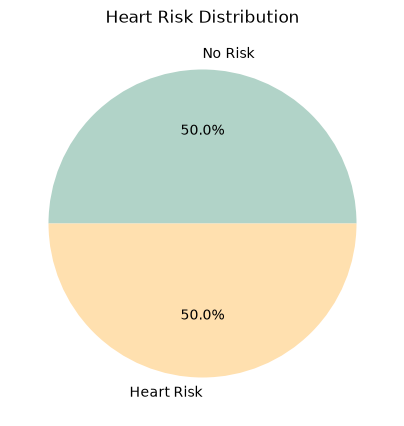

In [116]:
#Visual 1
heart_disease_count = df["Heart_Risk"].value_counts().sort_index()
plt.figure(figsize=(5,5))
plt.pie(heart_disease_count, labels=["No Risk", "Heart Risk"], autopct="%1.1f%%", colors=["#b1d3c8","#ffe0af"])
plt.title("Heart Risk Distribution")
plt.show()

**Insight**:
The pie chart reveals that 50% of patients are classified as having heart disease risk,and 50% are classified as having no heart disease risk. This dataset is balanced with no class imbalance issues.

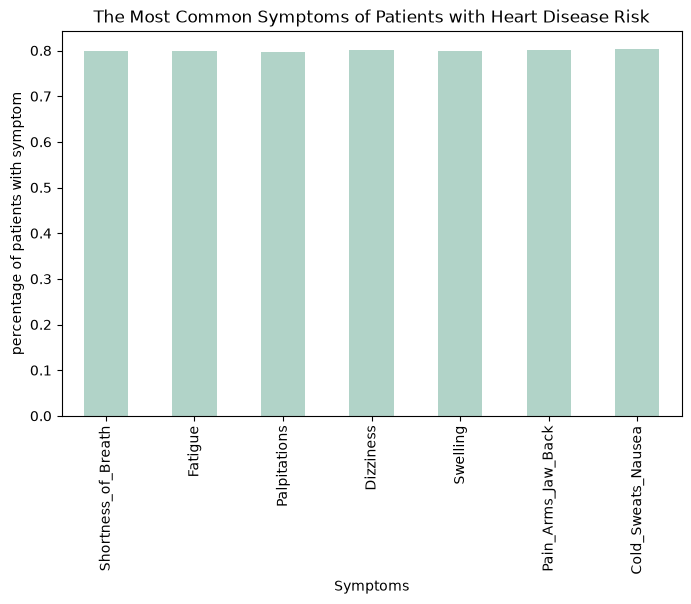

In [117]:
#Visual 2
risk_patients = df[df["Heart_Risk"]==1]

symptoms = ["Shortness_of_Breath", "Fatigue", "Palpitations", "Dizziness", "Swelling",
"Pain_Arms_Jaw_Back", "Cold_Sweats_Nausea"]
#calculating the mean of each symptom
symptom_mean = risk_patients[symptoms].mean()

plt.figure(figsize=(8,5))
symptom_mean.plot(kind="bar", color="#b1d3c8")
plt.title("The Most Common Symptoms of Patients with Heart Disease Risk")
plt.xlabel("Symptoms")
plt.ylabel("percentage of patients with symptom")
plt.show()


**insight**:
This bar chart reveals that all symptoms of patients with heart disease risk have similar prevelance, the same factors tend to occur together which indicates that some features may be highly correlated (which is why I  used the correlated heatmap next).

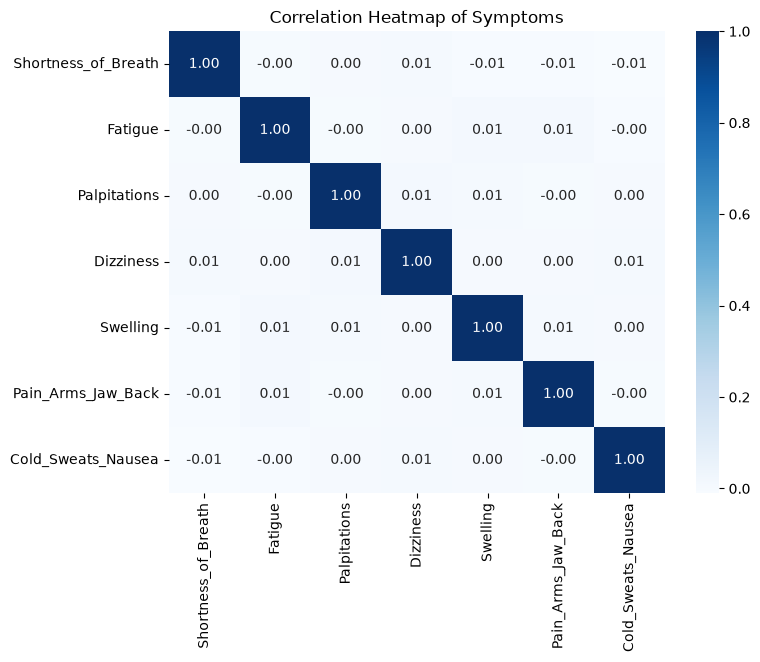

In [118]:
#visual 3
correlated_sym = risk_patients[symptoms].corr()

plt.figure(figsize=(8,6))
sns.heatmap(
    correlated_sym,
    annot=True,
    cmap="Blues",
    fmt=".2f"
)

plt.title("Correlation Heatmap of Symptoms")
plt.show()

**Insight**: After using the heatmap to check the independency of symptom features, it appears that while symptoms appear to happen together, they are still independent from each other which means having one doesn't predict having the other.

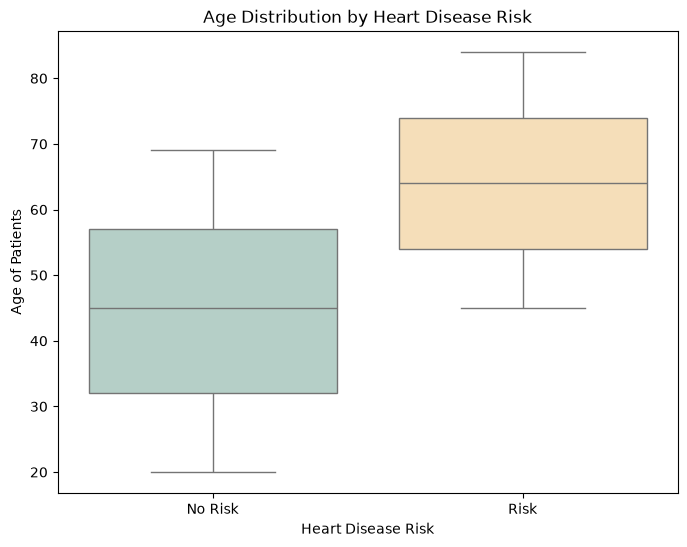

In [119]:
#visual 4
#Checking age distribution and if there are any outliers 
plt.figure(figsize=(8,6))

sns.boxplot(
    x="Heart_Risk",
    y="Age",
    data=df,
    hue="Heart_Risk",
    palette=["#b1d3c8","#ffe0af"],
    legend=False
)
plt.title("Age Distribution by Heart Disease Risk")
plt.xlabel("Heart Disease Risk")
plt.ylabel("Age of Patients")
plt.xticks([0,1], ["No Risk", "Risk"])
plt.show()

**Insight**:The boxplot shows that patients with heart disease risk belong to an older age group, with a higher median and age distribution compared to patients without heart disease risk, suggesting age may be associated with heart disease risk.

**Step 3**:
Data Cleaning
ckecking for missing values, duplicated values, or outliers, and then handling them properly.

**3.1** Is there any Missingness?

In [120]:
#checking if any column is missing a value and counting the total 
df.isnull().sum()

Chest_Pain             0
Shortness_of_Breath    0
Fatigue                0
Palpitations           0
Dizziness              0
Swelling               0
Pain_Arms_Jaw_Back     0
Cold_Sweats_Nausea     0
High_BP                0
High_Cholesterol       0
Diabetes               0
Smoking                0
Obesity                0
Sedentary_Lifestyle    0
Family_History         0
Chronic_Stress         0
Gender                 0
Age                    0
Heart_Risk             0
dtype: int64

**Insight**: The total null values is 0, which means that there is no missingness in the data.

**3.2** Is there duplicated values?

In [121]:
print(df.duplicated().sum())

6245


In [122]:
#It seems like there are duplicates, let's see the duplicated rows to decide how to handle them
print(df[df.duplicated()])

       Chest_Pain  Shortness_of_Breath  Fatigue  Palpitations  Dizziness  \
896             1                    1        1             1          1   
1062            1                    1        1             1          1   
1208            1                    1        0             1          1   
1301            0                    0        1             0          0   
1574            1                    1        1             0          1   
...           ...                  ...      ...           ...        ...   
69951           1                    1        1             1          1   
69967           0                    0        0             0          0   
69982           1                    0        0             0          0   
69989           0                    0        1             0          0   
69996           1                    1        1             0          1   

       Swelling  Pain_Arms_Jaw_Back  Cold_Sweats_Nausea  High_BP  \
896           1    

In [123]:
# After checking the result, I came to the realization that the duplicates may be normal since many patients
# could have the same combination of symptoms and most of the columns are binary too.
#the code below is because i want to check if they are true duplicates by checking if the age is identical
#too
print(df[df.duplicated(keep=False)].head(10))
#here i used "keep=False" which means count the first row as true (duplicate) as well, because i want
#to print all of them so this is better for viewing and comparing

    Chest_Pain  Shortness_of_Breath  Fatigue  Palpitations  Dizziness  \
14           1                    1        1             1          1   
22           0                    0        0             0          0   
34           1                    1        0             1          1   
40           1                    1        1             0          1   
49           1                    1        1             1          1   
65           1                    0        1             1          1   
68           1                    1        0             1          1   
69           1                    1        1             1          1   
81           0                    0        0             0          0   
86           1                    1        1             1          1   

    Swelling  Pain_Arms_Jaw_Back  Cold_Sweats_Nausea  High_BP  \
14         1                   1                   1        1   
22         0                   0                   0        0   
3

**Insight**: After the investigation, I found out that these are not true duplicates and do not need handling. The reason they are counted as duplicates is because some of them have the same pattern which is normal (because the dataset is binary so it has limited values).

**3.3** Is there any outliers ?

In [124]:
#Since all columns have only 2 possible values which are 0 or 1 there is no need to look for outliers in them 
#we need to look for outliers in the only numerical column and that is the "Age" column.
#I will use the IQR method that we studied to detect any numerical outliers

#First let's check the age statistics in general
print(df["Age"].describe())

count    70000.000000
mean        54.461986
std         16.410794
min         20.000000
25%         45.000000
50%         56.000000
75%         67.000000
max         84.000000
Name: Age, dtype: float64


In [125]:
#Now starting with the IQR Method 
q1 = df["Age"].quantile(0.25)
q3 = df["Age"].quantile(0.75)

IQR = q3 - q1

lower_bound = q1 - 1.5 * IQR
upper_bound = q3 + 1.5 * IQR 

#Lowest age acceptable is 12 and highest is 100 years old
print(f"Lower bound:{lower_bound}")
print(f"upper bound:{upper_bound}")

outliers = df[(df["Age"] < lower_bound) | (df["Age"] > upper_bound)]
print(f"Number of Outliers:{len(outliers)}")
print(f"Outliers values are:{outliers["Age"].values} ")

Lower bound:12.0
upper bound:100.0
Number of Outliers:0
Outliers values are:[] 


**Insight**:
After using the IQR method we see that there are no outliers at all which means that all the rows have an age value that is more than 12 and less than 100.

**3.4** Handling the inconvenience of data types:

In [126]:
#As I mentioned earlier the data types being float when most of the columns can accept only 0 or 1 is not convenient
#I also think it is optional to change it to (int) but it would be more professional this is why i am converting the type
#of all columns
df = df.astype(int)
#I ran this first

#Making sure data types have been converted 
print(df.dtypes)
print(df.head)

Chest_Pain             int64
Shortness_of_Breath    int64
Fatigue                int64
Palpitations           int64
Dizziness              int64
Swelling               int64
Pain_Arms_Jaw_Back     int64
Cold_Sweats_Nausea     int64
High_BP                int64
High_Cholesterol       int64
Diabetes               int64
Smoking                int64
Obesity                int64
Sedentary_Lifestyle    int64
Family_History         int64
Chronic_Stress         int64
Gender                 int64
Age                    int64
Heart_Risk             int64
dtype: object


<bound method NDFrame.head of        Chest_Pain  Shortness_of_Breath  Fatigue  Palpitations  Dizziness  \
0               0                    0        0             1          0   
1               0                    1        0             1          0   
2               1                    0        0             1          0   
3               1                    1        0             1          0   
4               0                    0        1             0          1   
...           ...                  ...      ...           ...        ...   
69995           0                    0        1             0          0   
69996           1                    1        1             0          1   
69997           0                    0        0             0          0   
69998           1                    1        0             1          1   
69999           1                    1        1             1          1   

       Swelling  Pain_Arms_Jaw_Back  Cold_Sweats_Nausea  

**Step 4:** Preprocessing


**4.1** Encoding:

I believe that there is no need for Encoding with our dataset since all columns already express the values in 0s and 1s and there are no categorical values to be handled.

**4.2** Feature Scaling:

scaling the features is important to make sure that no feature(column) overrides other columns by its values. In our case we'll scale the "Age" to make it on the same scale as other colmns(0s and 1s).

This scaling is important before using our models. I choosed 2 models which are Logistic Regression and Random forest. 
I chose them because logistic regression is the simple baseline, easy to interpret and report, while random forest handles binary features easily and can give stronger predictive performance.

Scaling is important for Logistic regression but not needed for Random forest since it works by splitting after checking a specific logic (if-else) so scaling does not change the result of splitting in random forest.

In [ ]:
#We'll start scaling BUT before we MUST split the data before scaling
#x is all the features without the goal and y is the goal(Label)
X = df.drop("Heart_Risk", axis=1)
y = df["Heart_Risk"]

#Data splitting
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

#Scaling ONLY age (needed for logistic regression)
scaler = StandardScaler()

X_train["Age"] = scaler.fit_transform(X_train[["Age"]])
X_test["Age"] = scaler.transform(X_test[["Age"]])


In [128]:
#Quick checkup that my split is correct
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(56000, 18)
(14000, 18)
(56000,)
(14000,)


**Step 5**: Dimensionality Reduction (PCA) 

Here I used PCA to know if all my features are important to give information or can PCA compress them and they still give the same information.

In [129]:
#Keeping 95% variance
pca = PCA(n_components=0.95)

#Fitting pca only on training data
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

print("Original features:", X_train.shape[1])
print("Components after PCA:", pca.n_components_)
print("Variance Retained:", pca.explained_variance_ratio_.sum())

Original features: 18
Components after PCA: 17
Variance Retained: 0.9700331821885421


**Insight**:

PCA compressed the data very little(from 18 to 17) while keeping 97% of variance. This tells us that the features were already unique and columns do not strongly overlap. so PCA didn't really simplify our dataset and that our dataset already contains distinct information.

**Step 6:** Modeling

The two models I'm using for my dataset are: Logistic regression and Random forest.

In [130]:
#using Logistic regression
lr = LogisticRegression(random_state=42)

lr.fit(X_train, y_train)

y_predict_lr = lr.predict(X_test)

#using Random forest
rf = RandomForestClassifier(random_state=42)

rf.fit(X_train, y_train)

y_predict_rf = rf.predict(X_test)


**Step 7**: Evaluation

After training and testing both models, in this step we will evaluate our model using accuracy, precision, recall, and F1 (the appropriate evaluation metrics for classification). 

In [131]:

#Evaluating Logistic regression
print("Accuracy of LR:", round(accuracy_score(y_test, y_predict_lr), 4))
print("Precision of LR:", round(precision_score(y_test, y_predict_lr), 4))
print("Recall of LR:", round(recall_score(y_test, y_predict_lr), 4))
print("F1 of LR:", round(f1_score(y_test, y_predict_lr), 4))

#Evaluating Random forest
print("")
print("Accuracy of RF:", round(accuracy_score(y_test, y_predict_rf), 4))
print("Precision of RF:", round(precision_score(y_test, y_predict_rf), 4))
print("Recall of RF:", round(recall_score(y_test, y_predict_rf), 4))
print("F1 of RF:", round(f1_score(y_test, y_predict_rf), 4))




Accuracy of LR: 0.9911
Precision of LR: 0.9911
Recall of LR: 0.9911
F1 of LR: 0.9911

Accuracy of RF: 0.9916
Precision of RF: 0.9924
Recall of RF: 0.9909
F1 of RF: 0.9916


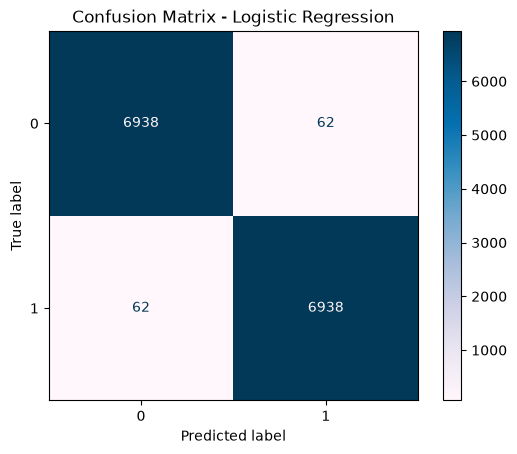

In [132]:
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_predictions(y_test, y_predict_lr, cmap="PuBu")
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

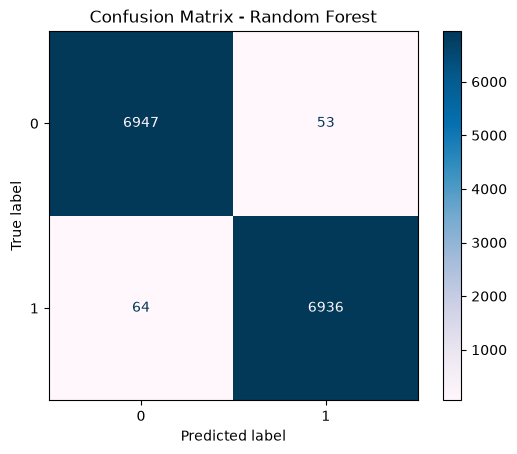

In [133]:
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_predictions(y_test, y_predict_rf, cmap="PuBu")
plt.title("Confusion Matrix - Random Forest")
plt.show()

**Insight**:

for both models The matrix shows in the top-left the patient who no heart disease risk and were predicted correctly, and on the botton-right it shows patients who has heart disease risk and were predicted correctly. This shows us that the models predicted the majority of patients correctly.
 while the bottom-left shows patients who actualy have heart disease risk but the models predicted as not having heart disease risk (FN), we can clearly see that random forest has higher FN which is what we are trying to avoide, and the top-right shows patients who were predicted as having risk wrongly (FP), for the logistic regression model they are wrong predictions too but they are also balanced which tells us that the model behaves symmetrically and doesn't favor one class over the other unlike the random forest.

In conclusion, minimizing the value of the FN is important in healthcare application, and that is another reason why I prefer the logistic regression model over the random forest.

**Step 8**: Conclusion


I think to compare between the models and choose the right one i need to ask 3 questions to get everything clear:

1.which model predicted more patients correctly generally? 

Random forest has higher score of accuracy than Logistic Regression

2.which model predicted heart risk as 1 and was more often correct ?(this mean this model has less chance of false alarms)

Random Forest has higher score of precision than Logistic regression

3.Which model catches more of the actual patients who have heart disease risk ?(this model has less chance of missing risky patients)

Logistic regression has a higher Recall than Random forest 

4.Which model balances precision and recall better ?

Random Forest does.

In conclusion, although Random forest has higher score but it is not just about the number, it's also about the problem. the more costing event in our case is missing risky patients (which Logistic regression has less probability of missing them), also random forest is more complex than logistic regression and as we saw in the evaluation the gap between them isn't something to even talk about, so since logistic regression (the simpler model) performed nearly as the random forest model (the complex model) in my opinion, I would consider logistic regression as the final appropriate model. Further work could focus on reducing F(N) since missing patients who actually have heart disease may have greater consequences.
